# NIDRA - NMES Wakefulness Calibration Analyis

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import liesl
import pingouin as pg
from glob import glob
import mne
from sleepstim.Analysis.NIDRA import pci
import os
from mne.preprocessing import ICA
import pandas as pd
import scipy
from mne_icalabel import label_components
import neurokit2 as nk
from tqdm import tqdm
import logging
import seaborn as sns
mne.set_log_level('ERROR')

# # Set plotting settings
# sns.set_context('talk')
# sns.set_style('white')
# sns.set_palette('colorblind')

# Initialize logging
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

def clean_ica(epochs):
    """
    Perform ICA cleaning on the provided epochs.

    Parameters:
    ----------
    epochs : mne.Epochs
        The epochs to be cleaned using ICA.

    Returns:
    -------
    clean_epochs : mne.Epochs
        The cleaned epochs after ICA correction.
    """
    # Initialize ICA
    ica = ICA(n_components=32, method='picard', random_state=42,
              fit_params=dict(ortho=True, extended=True)) 
    logger.info("Fitting ICA...")
    ica.fit(epochs.copy())
    
    # Automated component detection using ICLabel
    logger.info("Labeling ICA components using ICLabel...")
    ic_labels = label_components(epochs, ica, method="iclabel")
    labels = ic_labels["labels"]
    
    # Identify components to exclude (not 'brain' or 'other')
    exclude_idx = [idx for idx, label in enumerate(labels) if label not in ["brain", "other"]]
    logger.info(f"Initial ICA components to exclude (non-brain/other): {exclude_idx}")
    
    # Extract EDC channel data without squeezing
    EDC = epochs['nmes_stim'].copy().pick_channels(['EDC']).get_data()
    logger.debug(f"EDC shape before reshaping: {EDC.shape}")
    
    # Reshape EDC to (n_epochs, n_times) if necessary
    if EDC.ndim == 3 and EDC.shape[1] == 1:
        EDC = EDC[:, 0, :]  # Remove the singleton channel dimension
        logger.debug(f"EDC reshaped to: {EDC.shape}")
    elif EDC.ndim == 2:
        logger.debug("EDC shape is already as expected.")
    else:
        raise ValueError(f"Unexpected EDC shape: {EDC.shape}")
    
    # Get ICA sources
    sources = ica.get_sources(epochs['nmes_stim']).get_data()  # Shape: (n_epochs, n_components, n_times)
    logger.debug(f"ICA sources shape: {sources.shape}")
    
    # Ensure EDC and sources have compatible shapes
    if EDC.shape[0] != sources.shape[0]:
        raise ValueError("Mismatch between number of epochs in EDC and ICA sources.")
    
    sfreq = epochs.info['sfreq']  # Sampling frequency
    start_sample = int((-0.05 - epochs.tmin) * sfreq)
    end_sample = int((0.15 - epochs.tmin) * sfreq)
    logger.debug(f"Start sample: {start_sample}, End sample: {end_sample}")
    
    # Validate sample indices
    n_times = EDC.shape[1]
    if start_sample < 0 or end_sample > n_times:
        raise ValueError(f"start_sample ({start_sample}) or end_sample ({end_sample}) out of bounds for EDC with {n_times} samples.")
    
    r_values = []
    for epoch_idx in range(sources.shape[0]):
        for comp_idx in range(sources.shape[1]):
            # Extract the relevant time window for EDC and ICA component
            edc_segment = EDC[epoch_idx, start_sample:end_sample]
            comp_segment = sources[epoch_idx, comp_idx, start_sample:end_sample]
            
            # Compute Pearson correlation
            r, _ = scipy.stats.pearsonr(edc_segment, comp_segment)
            r_values.append([epoch_idx, comp_idx, r])
    
    # Create DataFrame of correlation values
    df = pd.DataFrame(r_values, columns=['Epoch_Index', 'Component_Index', 'Pearson_R'])
    
    # Determine the component with the highest average absolute correlation
    corr_means = df.groupby('Component_Index')['Pearson_R'].mean().abs()
    max_corr = corr_means.idxmax()
    corr = corr_means.max()
    
    logger.info(f'Component with max correlation: {max_corr}')
    logger.info(f'Max component and EDC correlation: {np.round(corr, 2)}')
    
    # Decide which components to exclude based on correlation threshold
    correlation_threshold = 0.5
    if corr >= correlation_threshold:
        ica.exclude = exclude_idx + [max_corr]
        logger.info(f"Excluding components based on correlation: {max_corr}")
    else:
        ica.exclude = exclude_idx
        logger.info("No additional components excluded based on correlation.")
    
    # Apply ICA to clean the epochs
    logger.info("Applying ICA to epochs...")
    clean_epochs = ica.apply(epochs.copy())
    
    return clean_epochs

In [2]:
# Data path
path = '/media/administrator/Sleep_Data/Raw/*/'

# Save path 
save_path = '/media/administrator/Sleep_Data/Processed/Calibration/'

# Preprocess
run = False

## Preprocess the data

In [3]:
# Iterate over files
if run: 
    for file in tqdm(glob(path + '*_nmes_recording_R00*.xdf')):

        # Extract subject and night
        subject = file.split('/')[-2].split('_')[0]
        night = file.split('/')[-2].split('_')[1]

        print(f'Processing {subject} - {night}...')

        # Load and preprocess data
        xdf_data = liesl.api.XDFFile(file)

        # Extract recording data and information
        eego = xdf_data['eego']
        eeg_data = eego.time_series
        ch_names = eego.channel_labels.copy()
        ch_types = eego.channel_types.copy()
        sfreq = int(eego.nominal_srate)
        times = eego.time_stamps.copy() 

        # Extract timestamps of classification markers
        nmes_stim_markers = [xdf_data['reiz-marker'].time_stamps[idx] for idx in 
                            range(len(xdf_data['reiz-marker'].time_series)) if 'real' in xdf_data['reiz-marker'].time_series[idx][0]]
        nmes_sham_markers = [xdf_data['reiz-marker'].time_stamps[idx] for idx in 
                            range(len(xdf_data['reiz-marker'].time_series)) if 'sham' in xdf_data['reiz-marker'].time_series[idx][0]]
        
        # Convert sham timestamps into indices and adjust
        sham_timestamps = nmes_sham_markers
        sham_indices = [np.argmin(np.abs(times - ts)) for ts in sham_timestamps]

        stim_timestamps = nmes_stim_markers
        stim_indices = [np.argmin(np.abs(times - ts)) for ts in stim_timestamps]

        # Create event arrays if stim or sham markers are present
        events_stim = np.array([[idx, 0, 1] for idx in stim_indices]) if len(stim_indices) > 0 else np.empty((0, 3))
        events_sham = np.array([[idx, 0, 2] for idx in sham_indices]) if len(sham_indices) > 0 else np.empty((0, 3))

        # Check dimensions of the events before concatenation
        if events_stim.shape[1] != events_sham.shape[1]:
            print(f"Dimension mismatch for {subject} - {night}. Skipping...")
            continue

        # Now concatenate the events if at least one array is not empty
        if len(events_stim) > 0 or len(events_sham) > 0:
            events_merged = np.concatenate([events_stim, events_sham], axis=0)
            events_merged = events_merged[np.argsort(events_merged[:, 0])]
        else:
            print(f"No events to process for {subject} - {night}. Skipping...")
            continue  # Just in case, skip this iteration if no events remain

        # Ensure that events_merged contains only integers
        events_merged = events_merged.astype(int)

        mapping = {
            1: 'nmes_stim', 
            2: 'nmes_sham', 
            }

        event_id = {
            'nmes_stim': 1, 
            'nmes_sham': 2, 
            }
        
        # Info about recording
        recording_length = np.round(eeg_data.shape[0]/60/sfreq, 2)
        print(f'The length of the recording : {recording_length} minutes of data at {sfreq} Hz sampling frequency.')

        # Check if the recording is too short
        if recording_length > 3:

            # Rename certain channels
            ch_names[ch_names.index('chan_7')] = 'ECG'
            ch_names[ch_names.index('chan_19')] = 'EDC'
            ch_names[ch_names.index('chan_20')] = 'EOG'
            ch_names[ch_names.index('chan_22')] = 'EMG_L'
            ch_names[ch_names.index('chan_23')] = 'EMG_R'

            # Reassign channel types
            ch_types[0:64] = ['eeg']*64
            ch_types[ch_names.index('ECG')] = 'ecg'
            ch_types[ch_names.index('EDC')] = 'emg'
            ch_types[ch_names.index('EOG')] = 'eog'
            ch_types[ch_names.index('EMG_L')] = 'emg'
            ch_types[ch_names.index('EMG_R')] = 'emg'

            # Channel Index
            chan_idx = [idx for idx in range(len(ch_names)) if 'EEG' not in ch_types[idx]]

            ## MNE procedure
            # Create MNE object
            info = mne.create_info(ch_names = list(np.asarray(ch_names)[chan_idx]), 
                                sfreq = sfreq,
                                ch_types = list(np.asarray(ch_types)[chan_idx]))

            # Create raw object
            raw = mne.io.RawArray(eeg_data[:,chan_idx].T, info)

            # Set montage
            raw.set_montage(mne.channels.make_standard_montage('standard_1005')) 

            # Add events 
            annot_from_events = mne.annotations_from_events(
                events=events_merged,
                event_desc=mapping,
                sfreq=raw.info["sfreq"],
                orig_time=None,
            )
            raw.set_annotations(annot_from_events)

            # Bandpass filter data
            raw.filter(1, 45, picks='eeg', n_jobs=-1)
            raw.filter(0.3, 35, picks='eog', n_jobs=-1)
            raw.filter(10, 200, picks=['EMG_L','EMG_R'], n_jobs=-1)

            # Process ECG separately 
            raw.apply_function(picks='ECG', 
                            fun=nk.ecg_clean, 
                            **dict(sampling_rate=raw.info['sfreq']))

            # Remove 'EDC' and 'ECG' from notch filtering
            channels_to_filter = [chan for chan in raw.ch_names if chan not in 'EDC']

            # Notch filter the data
            raw.notch_filter([50, 100, 150], 
                            picks=channels_to_filter, 
                            # method='spectrum_fit', 
                            n_jobs=-1)

            # Re-reference the data to common average
            raw.set_eeg_reference(ref_channels='average')
                
            # Bad channel detection
            bads, _ = nk.eeg_badchannels(raw.get_data(picks='eeg', units='uV'), distance_threshold=0.99)
            raw.info['bads'] = list(np.asarray(raw.ch_names)[bads])

            # Interpolate bads
            raw.interpolate_bads()

            # Create epochs based on nmes markers
            epochs = mne.Epochs(raw, events=events_merged, event_repeated='drop',
                                event_id=event_id, baseline=None,  
                                tmin=-3, tmax=3, preload=True)
            
            try:
                # Resample data
                raw.resample(256)
                epochs.resample(256)

                # Reject epochs with non-plausible voltages
                reject_criteria = dict(eeg=550e-6)
                epochs.drop_bad(reject=reject_criteria) 

                # Apply ICA
                try:
                    clean_epochs = clean_ica(epochs)
                except ValueError as e:
                    print(f'Error during ICA for {subject} - {night}: {str(e)}')
                    continue

                # Apply baseline correction
                clean_epochs.apply_baseline(baseline=(-3, -1.5))

                # Apply surface Laplacian interpretation
                final_epochs = mne.preprocessing.compute_current_source_density(clean_epochs) 

                # Time shift data by 217 ms
                final_epochs.shift_time(0.217, relative=True)

                # Plot data 
                ts_args = dict(spatial_colors=True, gfp=True, time_unit='s')
                topomap_args = dict(outlines='head', time_unit='s', time_format="%0.2f s")

                stim = final_epochs['nmes_stim'].average().crop(-0.25, 0.5)
                stim_plot = stim.plot_joint(title=f'NMES Stimulation (Wake)', 
                                            ts_args=ts_args,
                                            topomap_args=topomap_args)
                
                sham = final_epochs['nmes_sham'].average().crop(-0.25, 0.5)
                sham_plot = sham.plot_joint(title=f'NMES Sham Stimulation (Wake)', 
                                            ts_args=ts_args,
                                            topomap_args=topomap_args)

                contrast = mne.combine_evoked([stim, sham], weights=[1, -1])
                contrast_plot = contrast.plot_joint(title='NMES Stimulation Contrast (Wake)', 
                                                    ts_args=ts_args, 
                                                    topomap_args=topomap_args)
                
                # Save epochs and continuous data 
                save_path = '/media/administrator/Sleep_Data/Processed/Calibration/'
                raw.save(save_path + 'Raw/' + f'{subject}_{night}_calibration-raw.fif', overwrite=True)
                final_epochs.save(save_path + 'Epochs/' + f'{subject}_{night}_calibration-epochs.fif', overwrite=True)

                # Save plots
                stim_plot.savefig(save_path + 'Plots/' + f'{subject}_{night}_nmes_stim.png')
                sham_plot.savefig(save_path + 'Plots/' + f'{subject}_{night}_nmes_sham.png')
                contrast_plot.savefig(save_path + 'Plots/' + f'{subject}_{night}_nmes_contrast.png')

                # Close all plots
                plt.close('all')

                # delete variables
                del raw, epochs, clean_epochs, final_epochs, stim, sham, contrast, stim_plot, sham_plot, contrast_plot

            except RuntimeError as e:
                print(f'Error processing {subject} - {night}: {str(e)}')
                continue
        else:
            print(f"Recording too short for {subject} - {night}. Skipping...")

## Reload Epoched Data

In [4]:
def drop_bads_df(df, subject_nights=[('ChrSt', 1), ('UyDe', 1), ('IsEb', 2)]):
    from functools import reduce
    import operator
    # Ensure the night numbers are of the same type as in the DataFrame
    # If Night is a string in the DataFrame, convert the night numbers to strings
    subject_nights = [(subj, str(night)) if isinstance(df['Night'].iloc[0], str) else (subj, night) for subj, night in subject_nights]
    
    # Create masks for each condition to drop
    masks = [((df['Subject'] == subj) & (df['Night'] == night)) for subj, night in subject_nights]
    
    # Combine the individual masks with a logical OR
    if masks:
        combined_mask = reduce(operator.or_, masks)
    else:
        combined_mask = pd.Series([False] * len(df))
    
    # Apply the mask to filter out the rows
    df = df[~combined_mask]
    return df

### Plot Waveform of NMES ERP in Wake 

Processing file: /media/administrator/Sleep_Data/Processed/Calibration/Epochs/ViBu_1_calibration-epochs.fif
PCI for ViBu Night 1: 29.598694303535233
Processing file: /media/administrator/Sleep_Data/Processed/Calibration/Epochs/AnSt_2_calibration-epochs.fif
PCI for AnSt Night 2: 40.955138240333255
Processing file: /media/administrator/Sleep_Data/Processed/Calibration/Epochs/SvSchm_1_calibration-epochs.fif
PCI for SvSchm Night 1: 22.947682556746283
Processing file: /media/administrator/Sleep_Data/Processed/Calibration/Epochs/FlHa_2_calibration-epochs.fif
PCI for FlHa Night 2: 52.667882778468325
Processing file: /media/administrator/Sleep_Data/Processed/Calibration/Epochs/LiFe_1_calibration-epochs.fif
PCI for LiFe Night 1: 38.85588739207847
Processing file: /media/administrator/Sleep_Data/Processed/Calibration/Epochs/RaVe_2_calibration-epochs.fif
PCI for RaVe Night 2: 30.700139976036102
Processing file: /media/administrator/Sleep_Data/Processed/Calibration/Epochs/JaGr_2_calibration-epochs

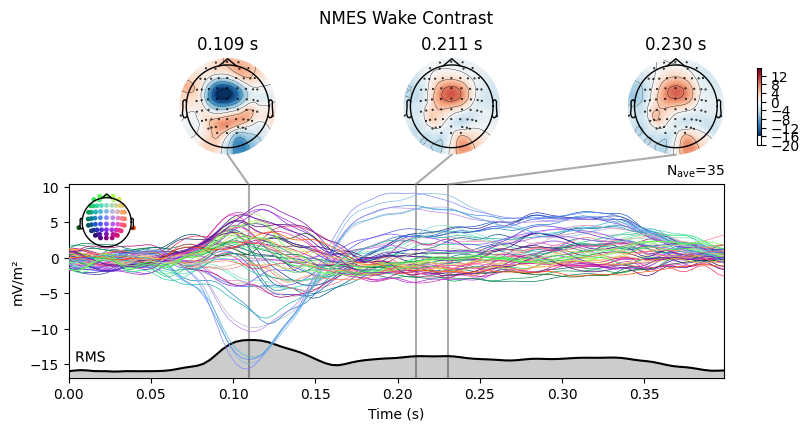

In [5]:
def analyze_wake_nmes_epochs_pci(epochs, subject, night):  
    """
    Analyze PCI for the difference between nmes_stim and nmes_sham epochs.

    Parameters:
    - epochs: MNE Epochs object containing both 'nmes_stim' and 'nmes_sham' conditions
    - subject: Subject identifier
    - night: Night identifier

    Returns:
    - df: pandas Series containing PCI data
    - signal_svd: SVD signal data
    - evk_diff: MNE Evoked object for stim - sham
    """
    # Create a copy of epochs
    epochs = epochs.copy()
    
    # Define PCI parameters with updated baseline and response windows
    par = {
        'baseline_window': (-0.2, 0.0), 
        'response_window': (0.0, 0.4), 
        'k': 1.2, 
        'min_snr': 1.1, 
        'max_var': 99,
        'embed': False,
        'n_steps': 100, 
        'avgref': False
    }
    
    # Compute evoked responses for 'nmes_stim' and 'nmes_sham'
    try:
        evk_stim = epochs['nmes_stim'].average()
    except KeyError:
        print(f"'nmes_stim' condition not found for Subject: {subject}, Night: {night}. Skipping.")
        return None, None, None
    
    try:
        evk_sham = epochs['nmes_sham'].average()
    except KeyError:
        print(f"'nmes_sham' condition not found for Subject: {subject}, Night: {night}. Skipping.")
        return None, None, None
    
    # Combine evoked responses to compute the difference: stim - sham
    evk_diff = mne.combine_evoked([evk_stim, evk_sham], weights=[1, -1])
    
    # Compute PCI on the difference
    pci_ = pci.calc_PCIst(evk_diff.get_data() * 1e3, evk_diff.times, full_return=True, **par)
    
    # Create a dictionary for the current analysis
    pci_dict = {
        'Subject': subject,
        'Night': night,
        'PCI': pci_['PCI'],
    } 
            
    # Convert to pandas Series
    df = pd.Series(pci_dict) 
    
    return df, pci_['signal_svd'], evk_diff

def process_all_subjects(save_path, output_csv=None, plot_results=True, plot_save_path=None):
    """
    Loop through all subject epoch files, analyze PCI, and aggregate results.

    Parameters:
    - save_path: Directory containing the epoch files.
    - output_csv: (Optional) File path to save the aggregated PCI results.
    - plot_results: (Optional) If True, generate and optionally save plots.
    - plot_save_path: (Optional) Directory to save plots if plot_results is True.

    Returns:
    - aggregated_df: pandas DataFrame with PCI results for all subjects.
    - grand_avg_diff: MNE Evoked object of grand average difference (nmes_stim - nmes_sham)
    """
    # Define the path pattern for epoch files
    epoch_pattern = os.path.join(save_path, 'Epochs', '*calibration-epochs.fif')
    epochs_files = glob(epoch_pattern)
    
    # Initialize a list to collect PCI data
    pci_data = []
    
    # Initialize a list to collect evk_diff for grand average
    evk_diff_list = []
    
    # Initialize a figure for plotting SVD signals if plotting is enabled
    if plot_results:
        plt.figure(figsize=(10, 6))
    
    # Loop through each epoch file
    for epoch_file in epochs_files:
        print(f'Processing file: {epoch_file}')
        
        # Extract subject and night information from the filename
        filename = os.path.basename(epoch_file)
        try:
            subject, night = filename.split('_')[:2]
        except ValueError:
            print(f'Filename {filename} does not conform to expected format. Skipping.')
            continue
        
        # Read the epochs
        try:
            epochs = mne.read_epochs(epoch_file) 
        except Exception as e:
            print(f'Error reading {epoch_file}: {e}')
            continue
        
        # Analyze PCI and get the difference evoked response
        result = analyze_wake_nmes_epochs_pci(epochs, subject, night)
        if result[0] is None:
            continue  # Skip if analysis was not successful
        epoch_pci, epoch_svd, evk_diff = result
        pci_data.append(epoch_pci)
        evk_diff_list.append(evk_diff)
        print(f'PCI for {subject} Night {night}: {epoch_pci["PCI"]}')
        
        # Plot SVD signal if enabled
        if plot_results and epoch_svd is not None:
            # Ensure that the time vector matches the cropped epochs
            svd_times = evk_diff.times  # Using the actual times from evk_diff
            plt.plot(svd_times, epoch_svd.mean(axis=0), label=f'{subject}_{night}', alpha=0.5)
    
    # Aggregate all PCI data into a DataFrame
    aggregated_df = pd.DataFrame(pci_data)
    
    # Compute grand average of the difference evoked responses using combine_evoked
    if evk_diff_list:
        grand_avg_diff = mne.grand_average(evk_diff_list)
        print('Grand average of (nmes_stim - nmes_sham) computed successfully.')
    else:
        grand_avg_diff = None
        print('No evoked differences to compute grand average.')
    
    # Save the aggregated PCI data if a path is provided
    if output_csv:
        aggregated_df.to_csv(output_csv, index=False)
        print(f'Aggregated PCI data saved to {output_csv}')
    
    # Finalize and save/show the plot
    if plot_results:
        plt.xlabel('Time (s)')
        plt.ylabel('SVD Signal Mean')
        plt.title('SVD Signal Across Subjects (nmes_stim - nmes_sham)')
        plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
        plt.tight_layout()
        
        if plot_save_path:
            os.makedirs(plot_save_path, exist_ok=True)
            plot_file = os.path.join(plot_save_path, 'svd_signals_grand_average.png')
            plt.savefig(plot_file, dpi=300)
            print(f'SVD signals plot saved to {plot_file}')
        else:
            plt.show()
    
    return aggregated_df, grand_avg_diff

# Usage Example:
save_path = '/media/administrator/Sleep_Data/Processed/Calibration/'
results_df, grand_avg_diff = process_all_subjects(
    save_path,
    output_csv='pci_results.csv',
    plot_results=False,  # Set to False if you don't want to generate plots
    plot_save_path='plots/'  # Ensure this directory exists or will be created
)

# Optionally, you can visualize the grand average evoked response
if grand_avg_diff is not None:
    grand_avg_diff.crop(0, 0.4).plot_joint(title='NMES Wake Contrast', 
                                           ts_args=dict(gfp=True), 
                                           topomap_args=dict(time_unit='s'))

In [6]:
# Load sleep pci results
sleep_pci_results = pd.read_pickle('/media/administrator/Sleep_Data/Processed/Statistics/df_pci.p')
sleep_pci_results = drop_bads_df(sleep_pci_results)
print(sleep_pci_results.Latency.unique())
sleep_pci_results = sleep_pci_results[sleep_pci_results.Latency == (0.0, 0.3)].reset_index(drop=True)

[(0.025, 0.225) (0, 0.3) (0.2, 0.4) (0.025, 0.8) (0.18, 0.28) (0.35, 0.6)
 (1, 1.5) (0.025, 1.5)]


In [7]:
# Merge wake and sleep pci results around subject and night
merged_pci_results = pd.merge(results_df, sleep_pci_results, on=['Subject', 'Night'], suffixes=('_wake', '_sleep'))
merged_pci_results = merged_pci_results[merged_pci_results.Mode=='nmes'].reset_index(drop=True)

### Correlation difference between PCI in Wake and NREM Sleep 

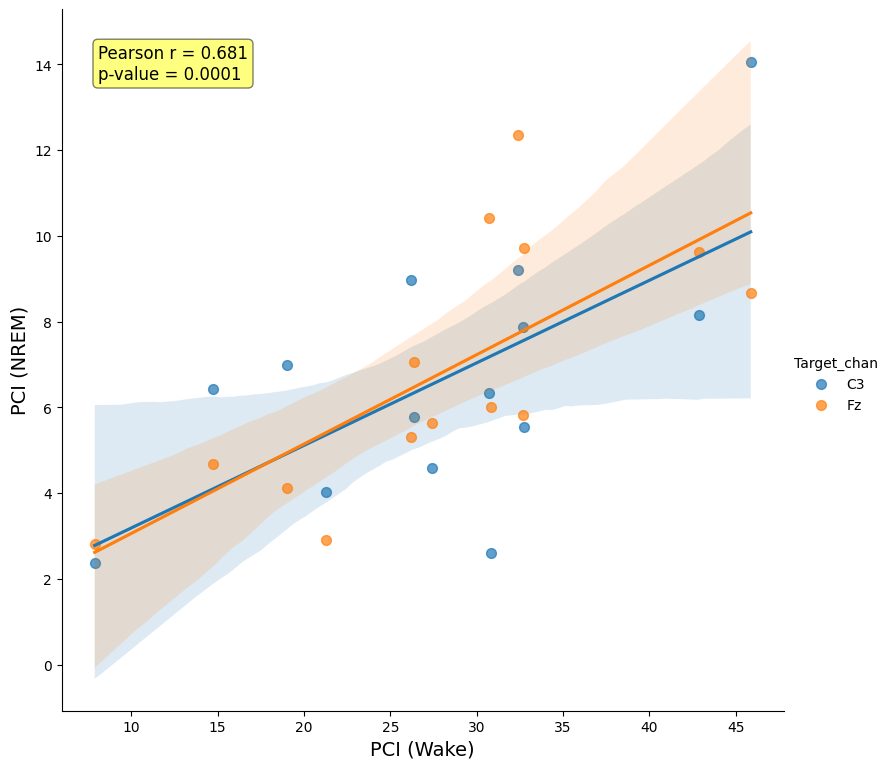

Plot saved as '/media/administrator/Sleep_Data/Processed/Calibration/Plots/pci_correlation_plot.png'
Pearson correlation: r = 0.681, p-value = 0.000


In [8]:
def plot_pci_correlation(merged_pci_results, x_col='PCI_wake', y_col='PCI_sleep', save_fig=False, save_path='pci_correlation_plot.png'):
    """
    Plots the relationship between wake and sleep PCI with Pearson correlation and p-value,
    including detailed distributions.

    Parameters:
    - merged_pci_results: pandas DataFrame containing PCI data with specified columns.
    - x_col: Column name for wake PCI.
    - y_col: Column name for sleep PCI.
    - save_fig: Boolean indicating whether to save the figure.
    - save_path: File path to save the figure if save_fig is True.
    """
    # Check if the necessary columns exist
    if not all(col in merged_pci_results.columns for col in [x_col, y_col]):
        raise ValueError(f"DataFrame must contain '{x_col}' and '{y_col}' columns.")
    
    # Drop rows with NaN values in the specified columns
    data = merged_pci_results#[[x_col, y_col]].dropna()
    
    # Compute Pearson correlation
    r, p = scipy.stats.pearsonr(data[x_col], data[y_col])
    
    # Set Seaborn theme
    #sns.set(style="whitegrid")
    
    # Initialize the jointplot with KDE for better distribution visualization
    # joint = sns.jointplot(
    #     data=data,
    #     x=x_col,
    #     y=y_col,
    #     kind='reg',          # Regression plot
    #     height=8,            # Size of the plot
    #     ratio=5,             # Ratio of joint axes to marginal axes
    #     #color='teal',
    #     scatter_kws={'s': 50, 'alpha': 0.7},
    #     #line_kws={'color': 'red'}
    # )

    joint = sns.lmplot(
        data=data,
        x=x_col,
        y=y_col,
        hue='Target_chan',
        height=8,            # Size of the plot
        #ratio=5,             # Ratio of joint axes to marginal axes
        #color='teal',
        scatter_kws={'s': 50, 'alpha': 0.7},
        #line_kws={'color': 'red'}
    )
    
    
    # Set axis labels with increased font size
    joint.set_axis_labels('PCI (Wake)', 'PCI (NREM)', fontsize=14)
    
    # Add an overall title
    #plt.suptitle('Relationship Between Wake and Sleep PCI', fontsize=16)
    
    # Adjust the title position to prevent overlap with the plot
    plt.subplots_adjust(top=0.95)
    
    # Annotate Pearson correlation coefficient and p-value on the plot
    annotation_text = f'Pearson r = {r:.3f}\np-value = {p:.4f}'
    # Position the annotation in the upper left corner of the scatter plot
    plt.annotate(
        annotation_text,
        xy=(0.05, 0.95),
        xycoords='axes fraction',
        fontsize=12,
        horizontalalignment='left',
        verticalalignment='top',
        bbox=dict(boxstyle="round,pad=0.3", fc="yellow", alpha=0.5)
    )
    
    # Show plot
    plt.show()
    
    # Save the plot if requested
    if save_fig:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Plot saved as '{save_path}'")
    
    # Print correlation results
    print(f'Pearson correlation: r = {r:.3f}, p-value = {p:.3f}')

    # Close the plot
    plt.close()

# Usage:
plot_pci_correlation(
    merged_pci_results,
    x_col='PCI_wake',
    y_col='PCI_sleep',
    save_fig=True, 
    save_path='/media/administrator/Sleep_Data/Processed/Calibration/Plots/pci_correlation_plot.png'
)

### Boxplot difference between PCI in NREM Sleep and Wake 

In [9]:
# Melt the DataFrame
df_long = pd.melt(
    merged_pci_results,
    id_vars=['Subject', 'Night', 'Target_chan', 'Mode', 'Latency'],
    value_vars=['PCI_wake', 'PCI_sleep'],
    var_name='Session',
    value_name='PCI'
)

# Rename the Session values
df_long['Session'] = df_long['Session'].replace({
    'PCI_wake': 'Wake',
    'PCI_sleep': 'NREM'
})

# Optional: Sort the DataFrame for better readability
df_long = df_long.sort_values(by=['Subject', 'Night', 'Session']).reset_index(drop=True)

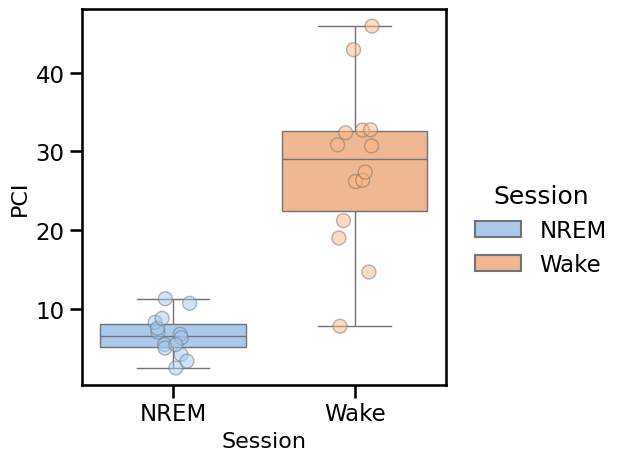

In [22]:
# Set plotting settings
with sns.plotting_context('talk'):
    # Box plot of PCI values in wake and sleep
    g = sns.catplot(
        data=df_long.groupby(['Session','Subject']).mean(numeric_only=True),
        kind="box",
        x="Session",
        y="PCI",
        hue="Session",
        palette="pastel",
        legend=True,
        showfliers=False,
    )

    # include points for data 
    g.map_dataframe(sns.stripplot, 
                    x="Session",
                    y="PCI", 
                    hue="Session", 
                    dodge=False, 
                    palette="pastel",
                    size=10, 
                    alpha=0.5, 
                    linewidth=1)

    g.set_axis_labels("Session", "PCI", fontsize=16)
    g.set_titles("{col_name} ({row_name})", size=16)

    for ax in g.axes.ravel():
        ax.spines['top'].set_visible(True)
        ax.spines['right'].set_visible(True)

In [11]:
df = df_long.groupby(['Session','Subject']).mean(numeric_only=True).reset_index()

T-test between Wake and NREM PCI: t(27) = 9.62, p = 2.80e-07


/home/administrator/anaconda3/envs/NDS/lib/python3.10/site-packages/pingouin/plotting.py:573: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  data["wthn"] = data[within].replace({_ordr: i for i, _ordr in enumerate(order)})


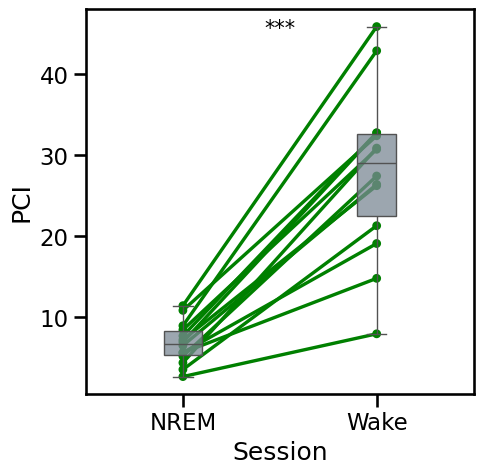

In [14]:
# Paired plot with pingouin

# Set plotting settings
with sns.plotting_context('talk'):
    # Compute paired t-test
    t_stat, p_val = scipy.stats.ttest_rel(df[df['Session'] == 'Wake']['PCI'], df[df['Session'] == 'NREM']['PCI'])
    print(f'T-test between Wake and NREM PCI: t({len(df) - 1}) = {t_stat:.2f}, p = {p_val:.2e}')

    # Paired plot visualization
    fig2, ax2 = plt.subplots(figsize=(5, 5))
    pg.plot_paired(data=df, 
                dv='PCI',
                within='Session', 
                subject='Subject',
                boxplot_in_front=True, 
                ax=ax2)
    #ax2.set_title(f'\nT: {t_stat:.2f}, p = {p_val:.2e}')
    ax2.set_xlabel('Session')
    ax2.set_ylabel('PCI')

    # Determine significance level and annotate the plot
    if p_val < 0.001:
        significance = '***'
    elif p_val < 0.01:
        significance = '**'
    elif p_val < 0.05:
        significance = '*'
    else:
        significance = 'n.s.'
    plt.text(0.5, .95, significance, ha='center', va='center', 
            transform=ax2.transAxes, fontsize=15)
    #plt.savefig(f'{fig_path}{param}_ttest.png')
    #sns.despine()